In [39]:
import sys
sys.path.insert(0, '..')

import random
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


from sklearn.metrics import roc_auc_score

# import label encoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold


from sklearn.model_selection import GridSearchCV, LeaveOneOut, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
from itertools import cycle

from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

import warnings
import copy

from matplotlib.lines import Line2D
from utils.utils import *

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
np.random.seed(1)
random.seed(42)

display_names = {'IL6':'IL-6','IL10':'IL-10','IL18':'IL-18','IL17':'IL-17','IL22':'IL-22','IL1B':'IL-1\u03b2','TNFa':'TNF-\u03b1', 'IL23':'IL-23'} 

# color order UC+ is tab:red, UC- is tab:orange, and control is tab:blue    
color_dict={'UC+symptoms':'tab:red', 'UC-symptoms':'tab:orange', 'control':'tab:blue'}
color_order=['tab:red', 'tab:orange', 'tab:blue']



figures='../paper_and_outputs/figures/'
data_location = '../measurement_data/'
ibd_data_name = 'IBD_Snapper.xlsx'
ibd_data_full_path = data_location+ibd_data_name
statistical_data_path = '../paper_and_outputs/tables/statistical_data_tables.xlsx'
extended_data_path = '../paper_and_outputs/tables/extended_data_tables.xlsx'
human_svg_path= '../aux_files/man-woman-icon.svg'


conc_epsilon= 0 #epsilon value if added to concentrations but we dont add it
scale= 3.29
dilution_factor=8


In [40]:

def clean_cals_vals(cals, vals, conc_epsilon=0):
  melted_cals = {}
  calambnames = ['amb1','amb2']
  calmeanpnames = ['meanp1','meanp2']
  calmeannames = ['mean_all1','mean_all2']
  for k, df in cals.items():
    # Average replicates in log space (geometric mean) for calibration curves
    df_avg = df.copy()

    #df_avg['amb'] = np.nan
    df_avg['amb'] = stats.gmean(df[calambnames], axis=1, nan_policy='omit')
    df_avg['lambda'] = stats.gmean(df[['lambda1','lambda2']], axis=1, nan_policy='omit')
    df_avg['meanp'] = stats.gmean(df[calmeanpnames],  axis=1,nan_policy='omit')
    df_avg['mean_all'] = stats.gmean(df[calmeannames],  axis=1,nan_policy='omit')

    df_final = df_avg[['conc', 'amb', 'lambda', 'meanp', 'mean_all']].copy()
    melted_cals[k] = df_final
    melted_cals[k]['amb_deviation']=np.std(df[calambnames], axis=1)
    melted_cals[k]['meanp_deviation']=np.std(df[calmeanpnames], axis=1)
    melted_cals[k]['mean_all_deviation']=np.std(df[calmeannames], axis=1)

  melted_vals = {}
  for k, df in vals.items():
    # Average replicates in log space (geometric mean) for calibration curves
    df_avg = df.copy()
  
    df_avg['amb'] = np.nan
    df_avg['amb'] = stats.gmean(df[['amb1','amb2']], axis=1, nan_policy='omit')

    df_avg['lambda'] = np.nan
    df_avg['lambda'] = stats.gmean(df[['lambda1','lambda2']], axis=1, nan_policy='omit')

    df_avg['meanp'] = np.nan
    df_avg['meanp'] = stats.gmean(df[['meanp1','meanp2']],  axis=1,nan_policy='omit')

    df_avg['mean_all'] = np.nan
    df_avg['mean_all'] = stats.gmean(df[['mean_all1','mean_all2']],  axis=1,nan_policy='omit')


    df_final = df_avg[['sample','type','amb', 'lambda', 'meanp', 'mean_all']].copy()
    melted_vals[k] = df_final

  cals = melted_cals
  vals = melted_vals

  for k, df in cals.items():
    cals[k]['conc'] = df['conc'].astype(float)+conc_epsilon
    cals[k]['amb'] = df['amb'].astype(float)
    cals[k]['meanp'] = df['meanp'].astype(float)

  for k, df in vals.items():
    vals[k]['amb'] = df['amb'].astype(float)
    vals[k]['meanp'] = df['meanp'].astype(float)
  return cals, vals

In [41]:
sheet1 = pd.read_excel(ibd_data_full_path, header=None) 

In [42]:
il22 = sheet1.iloc[1:36,0:7]
il23 = sheet1.iloc[1:36,8:15]
il6 = sheet1.iloc[1:36,16:23]
il10 = sheet1.iloc[1:36,24:41]

il17 = sheet1.iloc[38:73,0:7]
il18 = sheet1.iloc[38:73,8:15]
tnfa = sheet1.iloc[38:73,16:23]

In [43]:
cals = {}
data = {}

cals['IL22'] = il22.iloc[0:8,0:6]
cals['IL23'] = il23.iloc[0:8,0:6]
cals['IL6'] = il6.iloc[0:8,0:6]
cals['IL10'] = il10.iloc[0:8,0:6]
cals['IL17'] = il17.iloc[0:8,0:6]
cals['IL18'] = il18.iloc[0:8,0:6]
cals['TNFa'] = tnfa.iloc[0:8,0:6]

for k,c in cals.items():
  c.columns = ['conc', 'mw', 'amb1','amb2','meanp1','meanp2']
  c.reset_index(drop=True,inplace=True)
  c['conc'] = c['conc'].astype(float)
  c['mw'] = c['mw'].astype(float)
  c['amb1'] = c['amb1'].astype(float)
  c['amb2'] = c['amb2'].astype(float)
  c['meanp1'] = c['meanp1'].astype(float)
  c['meanp2'] = c['meanp2'].astype(float)
  cals[k] = c

for k,c in cals.items():
  c['amb1'] = pd.to_numeric(c['amb1'], errors='coerce')
  c['amb2'] = pd.to_numeric(c['amb2'], errors='coerce')
  c['meanp1'] = pd.to_numeric(c['meanp1'], errors='coerce')
  c['meanp2'] = pd.to_numeric(c['meanp2'], errors='coerce')
  cals[k] = c

for k,c in cals.items():
  c['lambda1'] = amb_to_on(c['amb1'])
  c['lambda2'] = amb_to_on(c['amb2'])
  c['mean_all1'] =c['lambda1']*c['meanp1']
  c['mean_all2'] =c['lambda2']*c['meanp2']
  cals[k] = c

data['IL22'] = il22.iloc[11:,1:7]
data['IL23'] = il23.iloc[11:,1:7]
data['IL6'] = il6.iloc[11:,1:7]
data['IL10'] = il10.iloc[11:,1:7]
data['IL17'] = il17.iloc[11:,1:7]
data['IL18'] = il18.iloc[11:,1:7]
data['TNFa'] = tnfa.iloc[11:,1:7]

for k,v in data.items():
  v.columns = ['sample','type','amb1','amb2','meanp1','meanp2']
  v.reset_index(drop=True,inplace=True)
  v['sample'] = v['sample'].astype(str)
  v['amb1'] = v['amb1'].replace("not enough sample", np.nan)
  v['amb2'] = v['amb2'].replace("not enough sample", np.nan)
  v['amb1'] = v['amb1'].astype(float)
  v['amb2'] = v['amb2'].astype(float)
  v['meanp1'] = v['meanp1'].astype(float)
  v['meanp2'] = v['meanp2'].astype(float)
  data[k] = v

for k,v in data.items():
  v['amb1'] = pd.to_numeric(v['amb1'], errors='coerce')
  v['amb2'] = pd.to_numeric(v['amb2'], errors='coerce')
  v['meanp1'] = pd.to_numeric(v['meanp1'], errors='coerce')
  v['meanp2'] = pd.to_numeric(v['meanp2'], errors='coerce')
  data[k] = v

for k,v in data.items():
  v['lambda1'] = amb_to_on(v['amb1'])
  v['lambda2'] = amb_to_on(v['amb2'])
  v['mean_all1'] =v['lambda1']*v['meanp1']
  v['mean_all2'] =v['lambda2']*v['meanp2']
  data[k] = v

In [44]:
cals,vals=clean_cals_vals(cals, data, conc_epsilon=conc_epsilon)

In [45]:
#rearange order of cytolines in vals and cals to match display order
order = ['TNFa','IL6', 'IL10',  'IL17','IL18', 'IL22', 'IL23']
cals = {k: cals[k] for k in order}
vals = {k: vals[k] for k in order}

/Users/teg14/anaconda3/envs/cocktail/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


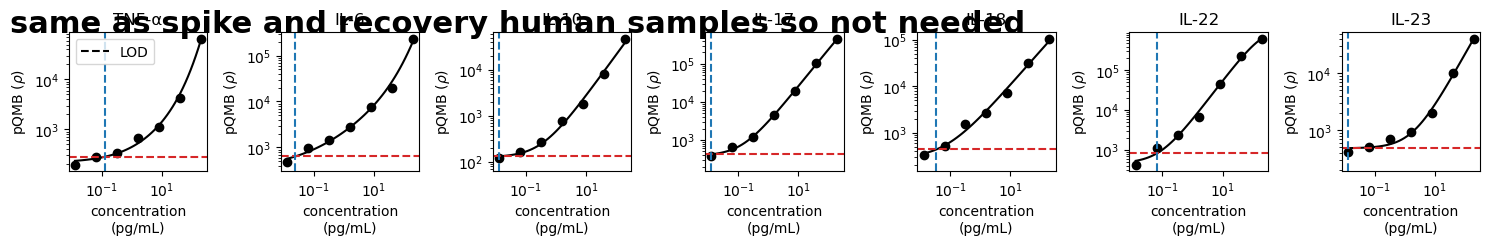

In [46]:
params = {} 
conclimits = {}
measurelimits = {}
llod = {}
llod_conc = {}
llod_conc_ll = {}
ulod = {}
ulod_conc = {}
ulod_conc_ll = {}
xf={}
yf={}
fig, axes = plt.subplots(1, 7, figsize=(15, 3))
axes = axes.flatten()



ambval='mean_all' #overloaded parameter name, could be 'amb' or 'mean_all'
ambdev='mean_all_deviation'

for i, (k, df) in enumerate(cals.items()):
  xf[k, ambval], yf[k, ambval], params[k, ambval] = cal_curve_fit(df, x_var='conc', y_var=ambval)

  # Get lowest non-zero concentration
  min_nonzero_conc = min(df[df['conc'] > 0]['conc'])
  max_nonzero_conc = max(df['conc'])
  amb_at_min_conc = df[df['conc'] == min_nonzero_conc][ambval]
  
  conclimits[k] = (min_nonzero_conc, max(df['conc']))
  measurelimits[k,ambval] = (min(amb_at_min_conc), max(df[ambval]))

  axes[i].plot(xf[k,ambval],yf[k,ambval], color='k')

  lasymp= df[ambval][7]# params[k,'amb'][0]
  lstandard_deviation=(df[ambdev][7]+df[ambdev][6])/2

  llod_std = lasymp+scale*lstandard_deviation


  llod_std= lasymp+scale*lstandard_deviation

  llod_lowest_conc=linear_5pl(min_nonzero_conc, *params[k, ambval])
  llod[k] = max(llod_std,llod_lowest_conc)

  llod_conc[k]=invlog5pl(llod[k], (params[k, ambval],conclimits[k],measurelimits[k, ambval]))
  
  axes[i].axhline(y=llod[k], color='tab:red', linestyle='--')
  axes[i].axvline(x=llod_conc[k], color='tab:blue', linestyle='--')

  conclimits[k] = (llod_conc[k], conclimits[k][1])
  measurelimits[k, ambval] = (llod[k], measurelimits[k, ambval][1])
  
  axes[i].scatter(df['conc'],df[ambval], color='k')

  axes[i].set_yscale('log')
  axes[i].set_xscale('log')
  axes[i].set_title(display_names.get(k))
  axes[i].set_xlabel('concentration\n(pg/mL)')
  axes[i].set_ylabel(r'pQMB ($\rho$)')
  #print LOD in figure
  #axes[i].text(0.05, 0.05, f'LOD: {llod_conc[k]:.3f} pg/mL', transform=axes[i].transAxes, fontsize=10, verticalalignment='top')

  axes[i].set_box_aspect(1)

custom_lines = [Line2D([0], [0], color='k', linestyle='--')]
axes[0].legend(custom_lines, ['LOD'], loc='upper left', fontsize=10)

# add letter d in upper left corner of the figure outside of the axes

# this uses the same standard curve as the SR

fig.text(0.01, 0.84, 'same as spike and recovery human samples so not needed', fontsize=22, fontweight='bold', va='top', ha='left')

plt.tight_layout()
#plt.savefig(figures+'ibd_calibration_curves.pdf', bbox_inches='tight')

In [47]:


# Create concentration table (average of replicates)
all_data = []


for k,v in vals.items():
  v['calculated_conc_amb'] = v[ambval].apply(inv5pl_after_lod, superparams=(params[k,ambval],conclimits[k],measurelimits[k, ambval]))
  #v['calculated_conc_mean'] = v[meanval].apply(invlog5pl_after_lod, superparams=(params[k,meanval],conclimits[k],measurelimits[k, meanval]))
  # chose calculated_conc from amb if amb is below 0.1
  v['calculated_conc_amb'] = v['calculated_conc_amb'] * dilution_factor
  v['protein'] = k
  vals[k] = v
  all_data.append(v)

#replace values in sample column to replace HDX with IBD
for v in all_data:
  v['sample'] = v['sample'].str.replace('HDX', 'IBD')


combined = pd.concat(all_data)
pivot_df = combined.pivot(index=['sample', 'type'], columns='protein', values='calculated_conc_amb').reset_index()

# Format table with sample (type) as row names
table = pivot_df.copy()
table['sample_label'] = table['sample'].astype(str) + ' (' + table['type'].astype(str) + ')'
concentration_table = table.set_index('sample_label')[order]


# replace HDX with IBD in sample labels



/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:80: RuntimeWarning: invalid value encountered in scalar power
  x = C * (((A - D) / (y - D)) ** (1/G) - 1) ** (1/B)
/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:80: RuntimeWarning: invalid value encountered in scalar power
  x = C * (((A - D) / (y - D)) ** (1/G) - 1) ** (1/B)
/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:80: RuntimeWarning: invalid value encountered in scalar power
  x = C * (((A - D) / (y - D)) ** (1/G) - 1) ** (1/B)
/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:80: RuntimeWarning: invalid value encountered in scalar power
  

In [48]:
df_plotting_melt = pivot_df.melt(
           id_vars=['sample', 'type'],
           value_vars=order,
           var_name='protein',
           value_name='value'
       )

In [49]:
df_plotting_melt

,sample,type,protein,value
0,IBD1,UC+symptoms,TNFa,1.056557
1,IBD10,UC-symptoms,TNFa,1.056557
2,IBD11,UC-symptoms,TNFa,1.056557
3,IBD12,UC-symptoms,TNFa,1.056557
4,IBD13,UC-symptoms,TNFa,1.056557
...,...,...,...,...
163,IBD5,UC+symptoms,IL23,0.102400
164,IBD6,UC+symptoms,IL23,0.102400
165,IBD7,UC+symptoms,IL23,0.628044
166,IBD8,UC+symptoms,IL23,7.294252


In [50]:
# perform a testtical test where we perform kruskal wallis with BH correction. Then after that perform rank test for only those that are significant with further BH correction on the pairwise test

#add mpatches
from statsmodels.stats.multitest import multipletests
from scipy.stats import kruskal, mannwhitneyu
import matplotlib.patches as mpatches

cytokines = df_plotting_melt['protein'].unique()
groups = df_plotting_melt['type'].unique()
kruskal_results = []
for cytokine in cytokines:
    data_cytokine = df_plotting_melt[df_plotting_melt['protein'] == cytokine]
    group_data = [data_cytokine[data_cytokine['type'] == group]['value'] for group in groups]
    stat, p_value = kruskal(*group_data)
    kruskal_results.append({'cytokine': cytokine, 'statistic': stat, 'p_value': p_value})

kruskal_df = pd.DataFrame(kruskal_results)

# Adjust p-values using BH correction
kruskal_df['p_value_adj'] = multipletests(kruskal_df['p_value'], method='fdr_bh')[1]
significant_cytokines = kruskal_df[kruskal_df['p_value_adj'] < 0.05]['cytokine'].tolist()

pairwise_results = []
for cytokine in significant_cytokines:
    data_cytokine = df_plotting_melt[df_plotting_melt['protein'] == cytokine]
    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            group1 = groups[i]
            group2 = groups[j]
            data1 = data_cytokine[data_cytokine['type'] == group1]['value']
            data2 = data_cytokine[data_cytokine['type'] == group2]['value']
            stat, p_value = mannwhitneyu(data1, data2)
            pairwise_results.append({
                'cytokine': cytokine,
                'group1': group1,
                'group2': group2,
                'statistic': stat,
                'p_value': p_value
            })

pairwise_df = pd.DataFrame(pairwise_results)

pairwise_df['p_value_adj'] = multipletests(pairwise_df['p_value'], method='fdr_bh')[1]




In [51]:
kruskal_df

,cytokine,statistic,p_value,p_value_adj
0,TNFa,0.870492,0.647105,0.647105
1,IL6,1.876152,0.391380,0.547932
2,IL10,2.267236,0.321867,0.547932
3,IL17,9.800056,0.007446,0.026062
4,IL18,5.175000,0.075208,0.175485
5,IL22,11.896552,0.002610,0.018272
6,IL23,0.968233,0.616241,0.647105


In [52]:
pairwise_df

,cytokine,group1,group2,statistic,p_value,p_value_adj
0,IL17,UC+symptoms,UC-symptoms,52.0,0.012777,0.025554
1,IL17,UC+symptoms,control,50.5,0.029841,0.044761
2,IL17,UC-symptoms,control,28.0,0.381574,0.457889
3,IL22,UC+symptoms,UC-symptoms,52.0,0.012777,0.025554
4,IL22,UC+symptoms,control,52.0,0.012777,0.025554
5,IL22,UC-symptoms,control,32.0,1.000000,1.000000


In [53]:

# Save kruskal results to statistical_data_tables

with pd.ExcelWriter(statistical_data_path, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
    kruskal_df.to_excel(writer, sheet_name='ibd_kruskal_tests', index=False)
    pairwise_df.to_excel(writer, sheet_name='ibd_MWU_tests', index=False)


In [54]:
def get_significance_stars(p_val):
        if p_val < 0.001:
            return '***'
        elif p_val < 0.01:
            return '**'
        elif p_val < 0.05:
            return '*'
        else:
            return 'ns'
    
pairwise_df['significance_stars'] = pairwise_df['p_value_adj'].apply(get_significance_stars)

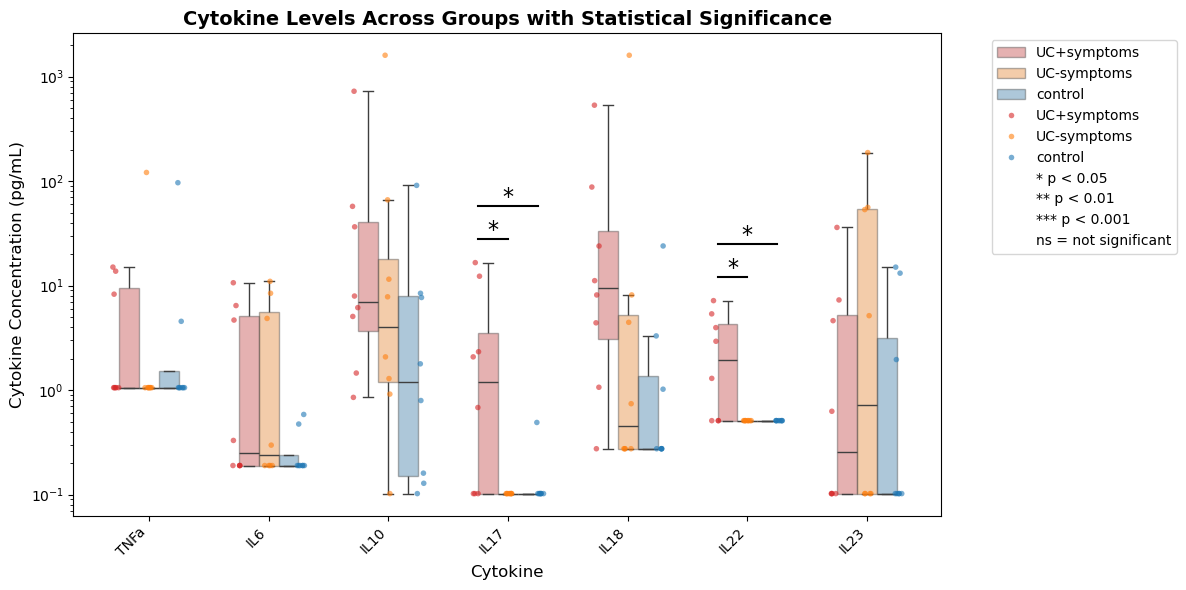

In [55]:
# Enhanced plotting with statistical annotations
def add_significance_annotations(ax, test_results, df_plotting_melt, fontsize=10):
    """
    Add significance stars to boxplot
    """
    cytokines = df_plotting_melt['protein'].unique()
    groups = ['UC+symptoms', 'UC-symptoms', 'control']
    
    for i, cytokine in enumerate(cytokines):
        cytokine_results = test_results[test_results['cytokine'] == cytokine]
        cytokine_data = df_plotting_melt[df_plotting_melt['protein'] == cytokine]
        
        # Get max value for this cytokine to position annotations
        max_val = cytokine_data['value'].max()
        
        # Define positions for different comparisons
        y_positions = [max_val * 1.7, max_val * 3.5, max_val * 5.5]
        
        # Group positions for each cytokine (adjusted for grouped bars)
        group_positions = {
            'UC+symptoms': i - 0.25,
            'UC-symptoms': i,  
            'control': i + 0.25
        }
        
        comparison_idx = 0
        for _, result in cytokine_results.iterrows():
            if result['significance_stars'] != 'ns':
                group1, group2 = result['group1'], result['group2']
                
                # Get x positions for the groups being compared
                x1 = group_positions[group1]
                x2 = group_positions[group2]
                
                # Y position for this comparison
                y_pos = y_positions[comparison_idx % len(y_positions)]
                
                # Draw line between groups
                ax.plot([x1, x2], [y_pos, y_pos], 'k-', linewidth=1.5)
                
                # Add star annotation
                ax.text((x1 + x2) / 2, y_pos*1.2, 
                       result['significance_stars'], 
                       ha='center', va='center', fontsize=fontsize, fontweight='regular')
                
                comparison_idx += 1

# Create the enhanced plot
plt.figure(figsize=(12, 6))

ax = sns.boxplot(data=df_plotting_melt, x='protein', y='value', hue='type', 
                 log_scale=10, boxprops={'alpha': 0.4}, showfliers=False, 
                 dodge=True, width=0.5, palette=color_dict)
sns.stripplot(data=df_plotting_melt, x='protein', y='value', hue='type',
              dodge=True, ax=ax, alpha=0.6, size=4, palette=color_dict)

# Add significance annotations
add_significance_annotations(ax, pairwise_df, df_plotting_melt, fontsize=16)

# Customize plot
plt.ylabel('Cytokine Concentration (pg/mL)', fontsize=12)
plt.xlabel('Cytokine', fontsize=12)
plt.title('Cytokine Levels Across Groups with Statistical Significance', fontsize=14, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add legend for significance levels
significance_legend = [
    mpatches.Patch(color='none', label='* p < 0.05'),
    mpatches.Patch(color='none', label='** p < 0.01'), 
    mpatches.Patch(color='none', label='*** p < 0.001'),
    mpatches.Patch(color='none', label='ns = not significant')
]

# Get existing legend and add significance legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + significance_legend, labels + ['* p < 0.05', '** p < 0.01', '*** p < 0.001', 'ns = not significant'], 
          bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [56]:
df=pivot_df
df

protein,sample,type,IL10,IL17,IL18,IL22,IL23,IL6,TNFa
0,IBD1,UC+symptoms,36.533368,2.082095,23.932268,5.370059,0.102400,0.190010,1.056557
1,IBD10,UC-symptoms,11.521859,0.102400,0.275178,0.510753,187.475956,0.190010,1.056557
2,IBD11,UC-symptoms,2.081424,0.102400,4.456209,0.510753,0.102400,0.190010,1.056557
3,IBD12,UC-symptoms,1.291061,0.102400,0.275178,0.510753,0.102400,0.190010,1.056557
4,IBD13,UC-symptoms,0.102400,0.102400,0.742131,0.510753,5.159425,4.855691,1.056557
5,IBD14,UC-symptoms,1600.000000,0.102400,1600.000000,0.510753,53.402578,10.991855,120.983011
6,IBD15,UC-symptoms,66.196817,0.102400,8.149807,0.510753,56.031293,0.297947,1.056557
7,IBD16,UC-symptoms,0.916809,0.102400,0.275178,0.510753,0.102400,0.190010,1.056557
8,IBD17,control,91.023236,0.102400,23.960402,0.510753,0.102400,0.190010,1.056557
9,IBD18,control,8.449371,0.102400,0.275178,0.510753,0.102400,0.190010,4.555721


In [57]:
with pd.ExcelWriter(extended_data_path, mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:  
    df.to_excel(writer, sheet_name='ibd_samples_concentrations', index=False)

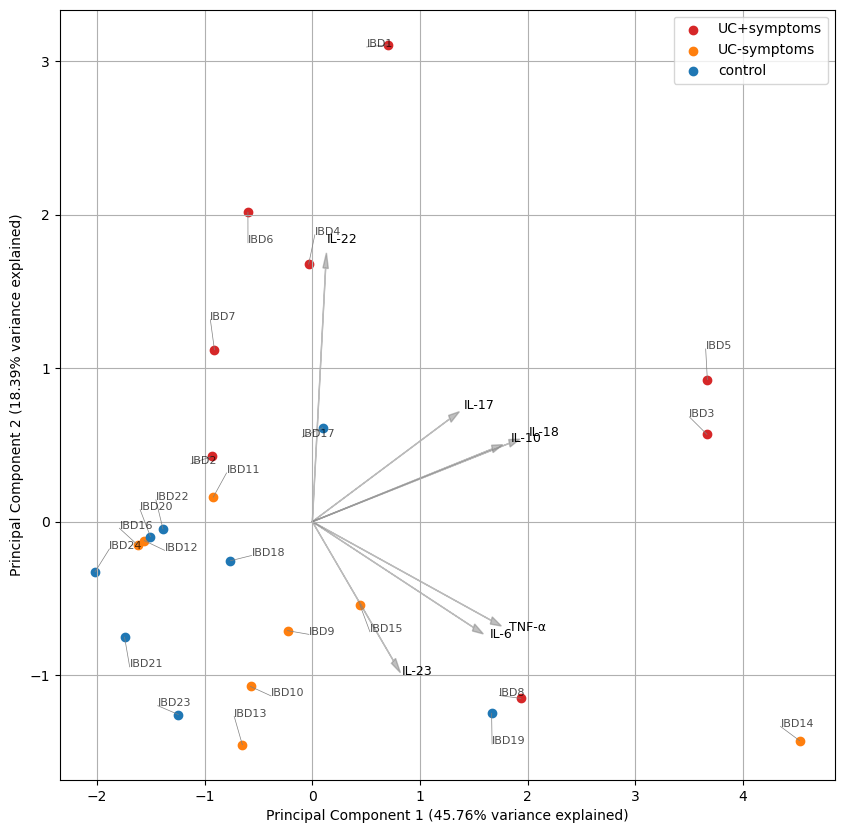

,PC1,PC2,Target,sample,type,IL10,IL17,IL18,IL22,IL23,IL6,TNFa
0,0.703573,3.107495,UC+symptoms,IBD1,UC+symptoms,3.598226,0.733374,3.175228,1.680839,-2.278869,-1.660677,0.055016
1,-0.574685,-1.073834,UC-symptoms,IBD10,UC-symptoms,2.444246,-2.278869,-1.290338,-0.671869,5.233651,-1.660677,0.055016
2,-0.920750,0.159987,UC-symptoms,IBD11,UC-symptoms,0.733052,-2.278869,1.494298,-0.671869,-2.278869,-1.660677,0.055016
3,-1.562970,-0.123193,UC-symptoms,IBD12,UC-symptoms,0.255464,-2.278869,-1.290338,-0.671869,-2.278869,-1.660677,0.055016
4,-0.650654,-1.453353,UC-symptoms,IBD13,UC-symptoms,-2.278869,-2.278869,-0.298229,-0.671869,1.640825,1.580151,0.055016
5,4.526730,-1.426905,UC-symptoms,IBD14,UC-symptoms,7.377759,-2.278869,7.377759,-0.671869,3.977859,2.397155,4.795650
6,0.441054,-0.540819,UC-symptoms,IBD15,UC-symptoms,4.192632,-2.278869,2.097994,-0.671869,4.025910,-1.210839,0.055016
7,-1.624641,-0.150772,UC-symptoms,IBD16,UC-symptoms,-0.086856,-2.278869,-1.290338,-0.671869,-2.278869,-1.660677,0.055016
8,0.095861,0.612182,control,IBD17,control,4.511115,-2.278869,3.176403,-0.671869,-2.278869,-1.660677,0.055016
9,-0.761277,-0.254793,control,IBD18,control,2.134092,-2.278869,-1.290338,-0.671869,-2.278869,-1.660677,1.516384


In [58]:
# import pca
from sklearn.decomposition import PCA

display_names = {
    'IL22': 'IL-22',
    'IL23': 'IL-23',
    'IL6': 'IL-6',
    'IL10': 'IL-10',
    'IL17': 'IL-17',
    'IL18': 'IL-18',
    'TNFa': 'TNF-α'
}

data=np.log(df.drop(columns=['sample', 'type']))

#scaler = StandardScaler()
#data_T =  data.T
#scaled_subjects_data_T = scaler.fit_transform(data.T)
#data=scaled_subjects_data_T.T

# 1. Standardize the data (optional but recommended)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data) # Exclude target_column from scaling

# 2. Perform PCA
pca = PCA(n_components=2) # Retain 2 principal components
principal_components = pca.fit_transform(scaled_data)

explained_variance_pc1 = pca.explained_variance_ratio_[0] * 100
explained_variance_pc2 = pca.explained_variance_ratio_[1] * 100

# 3. Create a DataFrame for plotting
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Target'] = df['type'] # Add back target column for coloring


# 4. Generate the plot
plt.figure(figsize=(10, 10))

for target_name in pca_df['Target'].unique():
    subset = pca_df[pca_df['Target'] == target_name]
    plt.scatter(subset['PC1'], subset['PC2'], label=target_name, color=color_dict[target_name])

# Calculate PCA loadings and add to plot
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loading_df = pd.DataFrame(loadings, columns=['PC1_loading', 'PC2_loading'], index=data.columns)

arrow_scale = 2  # Scale factor for arrows
text_scale = 2.2  # Scale factor for text



for i, cytokine in enumerate(data.columns):
    plt.arrow(0, 0, 
              loadings.T[0, i]*arrow_scale,  # Scale arrows for visibility
              loadings.T[1, i]*arrow_scale, 
              color='gray', alpha=0.5, head_width=0.05, head_length=0.1, lw=1)
    plt.text(loadings.T[0, i]*text_scale,
             loadings.T[1, i]*text_scale, 
             display_names[cytokine], 
             color='black', 
             fontsize=9)


# add sample label with a line from the point to the label spaced to avoid overlap
# add random rotational jitter to the label position to avoid overlap


# add random jitter constrained to a circle or radius 0.2 to the line endpoint and label position to avoid overlap
# the jitter is added to the line endpoint and label position to create a small separation between the point and the label, while keeping the label close enough to be associated with the point. The jitter is randomly generated for each point, ensuring that labels do not overlap and are more readable.
seed_value = 1 # Any integer can be used as a seed
rng = np.random.default_rng(seed=seed_value)

circle_radius = 0.2
random_angles = rng.uniform(0, 2 * np.pi, size=pca_df.shape[0])
#random_radii = np.random.uniform(0, circle_radius, size=pca_df.shape[0])
jitter_x = circle_radius * np.cos(random_angles)
jitter_y = circle_radius * np.sin(random_angles)
jitter = np.column_stack((jitter_x, jitter_y))
for i in range(pca_df.shape[0]):
    plt.plot([pca_df['PC1'][i], pca_df['PC1'][i] + jitter[i, 0]], [pca_df['PC2'][i], pca_df['PC2'][i] + jitter[i, 1]], color='gray', alpha=1, lw=0.5)
    plt.text(pca_df['PC1'][i] + jitter[i, 0], pca_df['PC2'][i] + jitter[i, 1], df['sample'][i], fontsize=8, alpha=0.7)


#for i in range(pca_df.shape[0]):
#    plt.text(pca_df['PC1'][i], pca_df['PC2'][i], df['sample'][i], fontsize=8, alpha=0.7)


plt.xlabel(f'Principal Component 1 ({explained_variance_pc1:.2f}% variance explained)')
plt.ylabel(f'Principal Component 2 ({explained_variance_pc2:.2f}% variance explained)')

# Add PCA loadings to the plot
##for i, (column, value) in enumerate(loading_df.iterrows()):
#    plt.arrow(0, 0, value['PC1_loading'], value['PC2_loading'], color='gray', alpha=0.5)
#    plt.text(value['PC1_loading'], value['PC2_loading'], column, fontsize=9)

#plt.title('PCA Plot of Data')
plt.legend()
plt.grid(True)
plt.savefig(figures + 'ibd_pca.pdf')
plt.show()


# add cytokine concentrations to the pc table along with sample lables and type
pca_conc_df = pd.concat([pca_df, df[['sample', 'type']].reset_index(drop=True), data.reset_index(drop=True)], axis=1)
pca_conc_df



In [59]:
data

protein,IL10,IL17,IL18,IL22,IL23,IL6,TNFa
0,3.598226,0.733374,3.175228,1.680839,-2.278869,-1.660677,0.055016
1,2.444246,-2.278869,-1.290338,-0.671869,5.233651,-1.660677,0.055016
2,0.733052,-2.278869,1.494298,-0.671869,-2.278869,-1.660677,0.055016
3,0.255464,-2.278869,-1.290338,-0.671869,-2.278869,-1.660677,0.055016
4,-2.278869,-2.278869,-0.298229,-0.671869,1.640825,1.580151,0.055016
5,7.377759,-2.278869,7.377759,-0.671869,3.977859,2.397155,4.795650
6,4.192632,-2.278869,2.097994,-0.671869,4.025910,-1.210839,0.055016
7,-0.086856,-2.278869,-1.290338,-0.671869,-2.278869,-1.660677,0.055016
8,4.511115,-2.278869,3.176403,-0.671869,-2.278869,-1.660677,0.055016
9,2.134092,-2.278869,-1.290338,-0.671869,-2.278869,-1.660677,1.516384


In [60]:
X=np.log(df.drop(columns=['sample', 'type']))
X=X.to_numpy()


y=df['type']
le = LabelEncoder()
y = le.fit_transform(y)

# Initialize LeaveOneOut
loo = LeaveOneOut()

# Store predictions
all_probabilities = []
all_true_labels = []
all_optimal_C = []



pipeline = Pipeline([
     ('scaler', StandardScaler()),
     ('classifier', LogisticRegression(penalty='l1', solver='liblinear', random_state=42, C=2))
])

# Parameter grid for the inner loop to find the best hyperparameters
param_grid = {
    'classifier__C': np.logspace(-1, 2, 30)
}

cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


# Iterate through each fold
for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Get class probabilities for the test sample
    inner_grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring='balanced_accuracy',
        n_jobs=-1
        )
    
    # Fit the pipeline on the training data
    inner_grid_search.fit(X_train, y_train)
    print(inner_grid_search.best_params_)

    probabilities = inner_grid_search.predict_proba(X_test)
    all_probabilities.append(probabilities[0])
    all_true_labels.append(y_test[0]) 
    all_optimal_C.append(inner_grid_search.best_params_['classifier__C'])


final_grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv, # Can also use a regular k-fold CV here if desired
    scoring='balanced_accuracy',
    n_jobs=-1
)

final_grid_search.fit(X, y)
final_model = final_grid_search.best_estimator_

coef=final_model.named_steps['classifier'].coef_
print((coef))

micro_roc_auc_ovr = roc_auc_score(
    all_true_labels,
    all_probabilities,
    multi_class="ovr",
    average="micro",
)

macro_roc_auc_ovr = roc_auc_score(
    all_true_labels,
    all_probabilities,
    multi_class="ovr",
    average="macro",
)

print(micro_roc_auc_ovr)
print(macro_roc_auc_ovr)
print(all_optimal_C)


{'classifier__C': np.float64(4.520353656360243)}
{'classifier__C': np.float64(0.41753189365604015)}
{'classifier__C': np.float64(0.5298316906283709)}


/Users/teg14/anaconda3/envs/cocktail/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


{'classifier__C': np.float64(0.41753189365604015)}
{'classifier__C': np.float64(0.41753189365604015)}
{'classifier__C': np.float64(18.873918221350976)}
{'classifier__C': np.float64(23.95026619987486)}
{'classifier__C': np.float64(0.32903445623126687)}
{'classifier__C': np.float64(1.373823795883263)}
{'classifier__C': np.float64(9.23670857187386)}
{'classifier__C': np.float64(2.2122162910704493)}
{'classifier__C': np.float64(0.6723357536499337)}
{'classifier__C': np.float64(0.6723357536499337)}
{'classifier__C': np.float64(3.562247890262442)}
{'classifier__C': np.float64(2.2122162910704493)}
{'classifier__C': np.float64(0.8531678524172808)}
{'classifier__C': np.float64(0.6723357536499337)}
{'classifier__C': np.float64(2.807216203941177)}
{'classifier__C': np.float64(9.23670857187386)}


/Users/teg14/anaconda3/envs/cocktail/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/teg14/anaconda3/envs/cocktail/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/teg14/anaconda3/envs/cocktail/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/teg14/anaconda3/envs/cocktail/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


{'classifier__C': np.float64(11.721022975334806)}
{'classifier__C': np.float64(11.721022975334806)}
{'classifier__C': np.float64(0.6723357536499337)}
{'classifier__C': np.float64(3.562247890262442)}
{'classifier__C': np.float64(0.32903445623126687)}
[[ 0.          1.57507358  0.          1.6024911   0.          0.
   0.        ]
 [ 0.03988075 -0.6618438   0.         -0.39237579  0.07327353  0.25957537
   0.        ]
 [-0.19020614  0.          0.         -0.53621501  0.         -0.53406152
   0.02186217]]
0.7552083333333334
0.7213541666666666
[np.float64(4.520353656360243), np.float64(0.41753189365604015), np.float64(0.5298316906283709), np.float64(0.41753189365604015), np.float64(0.41753189365604015), np.float64(18.873918221350976), np.float64(23.95026619987486), np.float64(0.32903445623126687), np.float64(1.373823795883263), np.float64(9.23670857187386), np.float64(2.2122162910704493), np.float64(0.6723357536499337), np.float64(0.6723357536499337), np.float64(3.562247890262442), np.fl

/Users/teg14/anaconda3/envs/cocktail/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/teg14/anaconda3/envs/cocktail/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


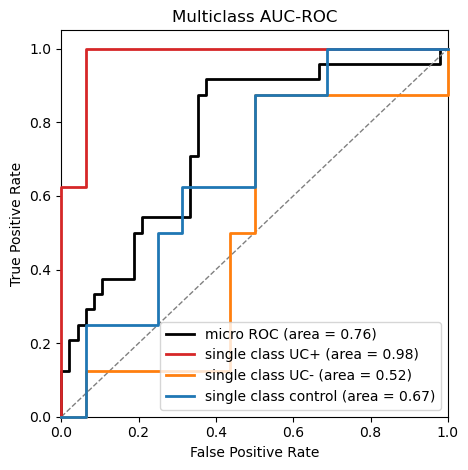

In [61]:
arr=np.array(all_true_labels)
num_categories = arr.max() + 1 

# Create a zero-filled matrix with rows equal to the array's size and columns equal to the number of categories
one_hot_encoded = np.zeros((arr.size, num_categories))

# Set the corresponding position to 1 for each element
one_hot_encoded[np.arange(arr.size), arr] = 1

y_test=one_hot_encoded
y_score=np.array(all_probabilities)
n_classes = y_score.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
lw=2

# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

fpr_grid = np.linspace(0.0, 1.0, 1000)

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(fpr_grid)
for i in range(n_classes):
    mean_tpr += np.interp(fpr_grid, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = fpr_grid
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure()
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label="micro ROC (area = {0:0.2f})".format(roc_auc["micro"]),
    color="black",
    linestyle="-",
    linewidth=lw,
)

# plt.plot(
#     fpr["macro"],
#     tpr["macro"],
#     label="macro ROC (area = {0:0.2f})".format(roc_auc["macro"]),
#     color="black",
#     linestyle=":",
#     linewidth=lw,
# )

colors = cycle(["tab:red", "tab:orange", "tab:blue"])
class_name = ['UC+','UC-','control']
for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=lw,
        label="single class " + class_name[i] + " (area = {0:0.2f})".format(roc_auc[i]),
        #alpha=0.7,
        zorder=3
    )

plt.gca().set_box_aspect(1)
for artist in plt.gca().get_children():
    artist.set_clip_on(False)

plt.plot([0, 1], [0, 1],"--", color='gray', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass AUC-ROC")
plt.legend(loc="lower right")

plt.tight_layout()
#plt.savefig(figures + 'multi_and_single_auc.pdf', bbox_inches='tight')
plt.show()

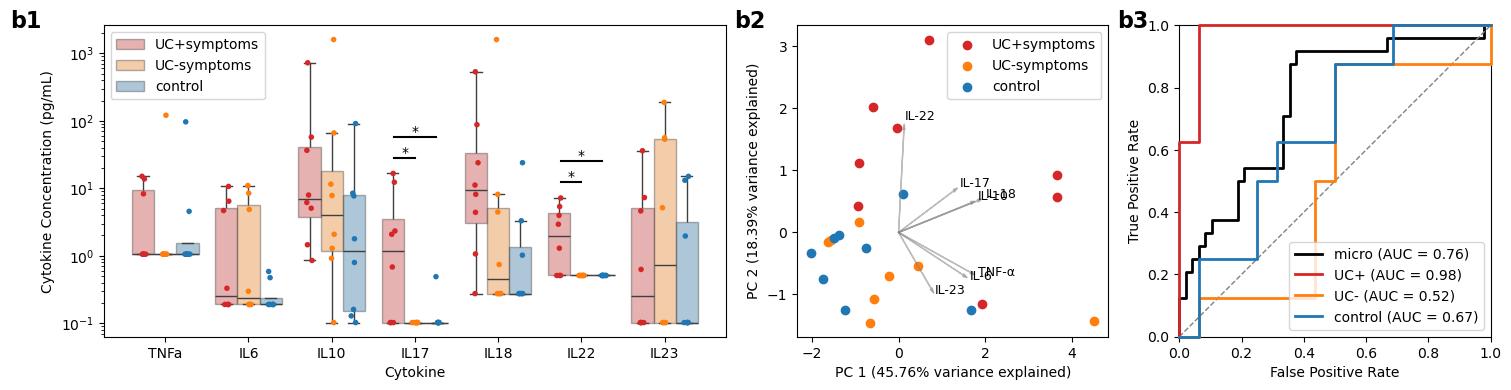

In [62]:
mosaic = """
AABC
"""
fig, ax_dict = plt.subplot_mosaic(mosaic,figsize=(15, 6), layout='constrained')

ax=ax_dict['A']


sns.boxplot(data=df_plotting_melt, ax=ax, x='protein', y='value', hue='type', 
                 log_scale=10, boxprops={'alpha': 0.4}, showfliers=False, 
                 dodge=True, palette=color_dict)
sns.stripplot(data=df_plotting_melt, x='protein', y='value', hue='type',
              dodge=True, ax=ax, size=4, palette=color_dict)

# Add significance annotations
add_significance_annotations(ax, pairwise_df, df_plotting_melt)

# Customize plot
ax.set_ylabel('Cytokine Concentration (pg/mL)')
ax.set_xlabel('Cytokine')

# Rotate x-axis labels for better readability
ax.set_box_aspect(0.5)
# Add legend for significance levels
significance_legend = [
    mpatches.Patch(color='none', label='* p < 0.05'),
    mpatches.Patch(color='none', label='** p < 0.01'), 
    mpatches.Patch(color='none', label='*** p < 0.001'),
    mpatches.Patch(color='none', label='ns = not significant')
]
ax.legend_.remove()
# Get existing legend and add significance legend
#handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[0:3] , labels[0:3], loc='upper left')



ax=ax_dict['B']

for target_name in pca_df['Target'].unique():
    subset = pca_df[pca_df['Target'] == target_name]
    ax.scatter(subset['PC1'], subset['PC2'], label=target_name, color=color_dict[target_name])

ax.set_xlabel(f'PC 1 ({explained_variance_pc1:.2f}% variance explained)')
ax.set_ylabel(f'PC 2 ({explained_variance_pc2:.2f}% variance explained)')

ax.legend()
#ax.grid(True)

for i, cytokine in enumerate(data.columns):
    ax.arrow(0, 0, 
              loadings.T[0, i]*arrow_scale,  # Scale arrows for visibility
              loadings.T[1, i]*arrow_scale, 
              color='gray', alpha=0.5, head_width=0.05, head_length=0.1, lw=1)
    ax.text(loadings.T[0, i]*text_scale, 
             loadings.T[1, i]*text_scale, 
             display_names[cytokine], 
             color='black', 
             fontsize=9)



ax.set_box_aspect(1)
ax=ax_dict['C']

ax.plot(
    fpr["micro"],
    tpr["micro"],
    label="micro (AUC = {0:0.2f})".format(roc_auc["micro"]),
    color="black",
    linestyle="-",
    linewidth=lw,
)

# ax.plot(
#     fpr["macro"],
#     tpr["macro"],
#     label="macro (AUC = {0:0.2f})".format(roc_auc["macro"]),
#     color="black",
#     linestyle=":",
#     linewidth=lw,
# )

colors = cycle(["tab:red", "tab:orange", "tab:blue"])
class_name = ['UC+','UC-','control']
for i, color in zip(range(n_classes), colors):
    ax.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=lw,
        label=class_name[i] + " (AUC = {0:0.2f})".format(roc_auc[i]),
        #alpha=0.7,
        zorder=3
    )

ax.set_box_aspect(1)
for artist in ax.get_children():
    artist.set_clip_on(False)

ax.plot([0, 1], [0, 1],"--", color='gray', lw=1)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.legend(loc="lower right")#bbox_to_anchor=(0.5, -0.2), loc='upper center')

#add a,b,c labels to subplots
subplot_labels = ['b1', 'b2', 'b3']
for ax, label in zip(ax_dict.values(), subplot_labels):
    ax.text(-0.1, 1.05, label, transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='right')


In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

def stratified_bootstrap_indices_multiclass(y, rng):
    """
    Stratified bootstrap resampling for multiclass labels.
    Preserves per-class counts in every resample.
    """
    y = np.asarray(y).astype(int)
    idx = np.arange(len(y))
    classes = np.unique(y)

    idx_bs_parts = []
    for c in classes:
        idx_c = idx[y == c]
        idx_bs_parts.append(rng.choice(idx_c, size=len(idx_c), replace=True))

    return np.concatenate(idx_bs_parts)

def multiclass_roc_with_bootstrap(
    y_true,
    P,                       # (n, K)
    B=5000,
    seed=0,
    grid_size=200,
    class_names=None,
):
    """
    Compute multiclass OvR ROC curves + bootstrap confidence bands.
    Also returns micro & macro AUC (OvR).
    """
    y_true = np.asarray(y_true).astype(int)
    P = np.asarray(P).astype(float)
    n, K = P.shape
    classes = np.arange(K)

    if class_names is None:
        class_names = [f"class {k}" for k in range(K)]

    # Binarize labels for OvR
    Y = label_binarize(y_true, classes=classes)  # (n, K)

    # Point estimate AUCs (OvR)
    auc_macro = roc_auc_score(Y, P, average="macro", multi_class="ovr")
    auc_micro = roc_auc_score(Y, P, average="micro", multi_class="ovr")
    auc_per_class = {}
    roc_point = {}

    # Per-class ROC (point estimate)
    for k in range(K):
        fpr_k, tpr_k, _ = roc_curve(Y[:, k], P[:, k], drop_intermediate=False)
        auc_k = roc_auc_score(Y[:, k], P[:, k])
        auc_per_class[k] = auc_k
        roc_point[k] = (fpr_k, tpr_k)

    # Micro-average ROC (point estimate)
    fpr_micro, tpr_micro, _ = roc_curve(Y.ravel(), P.ravel(), drop_intermediate=False)

    # Bootstrap setup
    rng = np.random.default_rng(seed)
    fpr_grid = np.linspace(0, 1, grid_size)

    # Store bootstrap TPRs for each class + micro
    tpr_boot = {k: np.zeros((B, grid_size), dtype=float) for k in range(K)}
    tpr_boot["micro"] = np.zeros((B, grid_size), dtype=float)

    # Store bootstrap AUCs
    auc_boot = {k: np.zeros(B, dtype=float) for k in range(K)}
    auc_boot["micro"] = np.zeros(B, dtype=float)
    auc_boot["macro"] = np.zeros(B, dtype=float)

    b = 0
    while b < B:
        idx_bs = stratified_bootstrap_indices_multiclass(y_true, rng)

        # Need all classes present (stratified bootstrap should guarantee, but keep safe)
        if len(np.unique(y_true[idx_bs])) < K:
            continue

        Yb = Y[idx_bs, :]
        Pb = P[idx_bs, :]

        # Per-class ROC + AUC
        for k in range(K):
            # Skip if degenerate (shouldn't happen with stratification)
            if len(np.unique(Yb[:, k])) < 2:
                continue

            fpr_b, tpr_b, _ = roc_curve(Yb[:, k], Pb[:, k], drop_intermediate=False)
            auc_boot[k][b] = roc_auc_score(Yb[:, k], Pb[:, k])

            tpr_i = np.interp(fpr_grid, fpr_b, tpr_b)
            tpr_i[0] = 0.0
            tpr_i[-1] = 1.0
            tpr_boot[k][b, :] = tpr_i

        # Micro-average ROC + AUC
        fpr_bm, tpr_bm, _ = roc_curve(Yb.ravel(), Pb.ravel(), drop_intermediate=False)
        auc_boot["micro"][b] = roc_auc_score(Yb, Pb, average="micro", multi_class="ovr")
        auc_boot["macro"][b] = roc_auc_score(Yb, Pb, average="macro", multi_class="ovr")

        tpr_im = np.interp(fpr_grid, fpr_bm, tpr_bm)
        tpr_im[0] = 0.0
        tpr_im[-1] = 1.0
        tpr_boot["micro"][b, :] = tpr_im

        b += 1

    # Summarize bootstrap bands
    bands = {}
    for key in list(range(K)) + ["micro"]:
        bands[key] = {
            "tpr_med": np.median(tpr_boot[key], axis=0),
            "tpr_lo": np.percentile(tpr_boot[key], 2.5, axis=0),
            "tpr_hi": np.percentile(tpr_boot[key], 97.5, axis=0),
        }

    auc_ci = {}
    for key in list(range(K)) + ["micro", "macro"]:
        lo, hi = np.percentile(auc_boot[key], [2.5, 97.5])
        auc_ci[key] = (lo, hi)

    return {
        "K": K,
        "class_names": class_names,
        "roc_point": roc_point,
        "fpr_micro": fpr_micro,
        "tpr_micro": tpr_micro,
        "fpr_grid": fpr_grid,
        "bands": bands,
        "auc_per_class": auc_per_class,
        "auc_micro": auc_micro,
        "auc_macro": auc_macro,
        "auc_ci": auc_ci,
        "auc_boot": auc_boot,
    }


# fix the colors in the plot_multiclass_roc function to match the colors in the previous plot
def plot_multiclass_roc(results, show_bands=True, show_micro=True, show_macro_in_legend=True, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    K = results["K"]
    names = results["class_names"]
    fpr_grid = results["fpr_grid"]

    # Diagonal
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

    # Per-class curves
    c=["tab:blue", "tab:orange", "tab:green"]
    for k in range(K):
        fpr_k, tpr_k = results["roc_point"][k]
        auc_k = results["auc_per_class"][k]
        lo, hi = results["auc_ci"][k]

        ax.plot(fpr_k, tpr_k, linewidth=2, color=c[k], zorder=3,
                label=f"{names[k]} (AUC={auc_k:.2f}, 95% CI {lo:.2f}-{hi:.2f})")

        if show_bands:
            lo_band = results["bands"][k]["tpr_lo"]
            hi_band = results["bands"][k]["tpr_hi"]
            ax.fill_between(fpr_grid, lo_band, hi_band, alpha=0.15, linewidth=0)

    # Micro-average curve
    if show_micro:
        auc_micro = results["auc_micro"]
        lo, hi = results["auc_ci"]["micro"]

        ax.plot(results["fpr_micro"], results["tpr_micro"],color='k', linewidth=2, linestyle=":",
                label=f"micro avg (AUC={auc_micro:.2f}, 95% CI {lo:.2f}-{hi:.2f})")

        if show_bands:
            lo_band = results["bands"]["micro"]["tpr_lo"]
            hi_band = results["bands"]["micro"]["tpr_hi"]
            ax.fill_between(fpr_grid, lo_band, hi_band, color='k', alpha=0.10,linewidth=0)

    # Macro-average only as text (usually not a curve)
    if show_macro_in_legend:
        auc_macro = results["auc_macro"]
        lo, hi = results["auc_ci"]["macro"]
        # Hack: empty plot for legend entry, but no line shown
        ax.plot([], [], label=f"macro avg (AUC={auc_macro:.2f}, 95% CI {lo:.2f}-{hi:.2f})")

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.01, 1.01)
    ax.legend(loc="lower right", frameon=True)
    ax.set_aspect('equal', adjustable='box')
    return ax


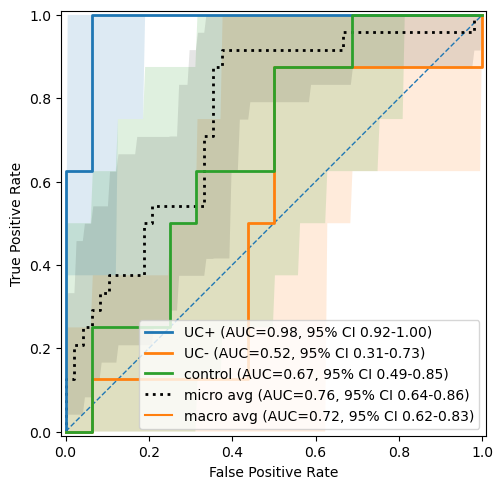

In [64]:
# y_true: shape (n,) with labels like 0,1,2
# P: shape (n,3) out-of-sample probs from nested outer CV

class_names = ["UC+", "UC-", "control"]

res = multiclass_roc_with_bootstrap(
    y_true=y,
    P=y_score,
    B=1000,
    seed=1,
    class_names=class_names
)

fig, ax = plt.subplots(figsize=(7,5))
plot_multiclass_roc(res, show_bands=True, show_micro=True, show_macro_in_legend=True, ax=ax)
plt.tight_layout()
plt.show()

In [65]:
#make a function create a histogram for the bootrrap AUC values for each class, the micro, and include a vertical line for the point estimate AUC, the median, and the 95% confidence interval
# add median auc as a vertical line in the histogram and add to legend

def plot_auc_bootstrap_histograms(results, ax_dict=None):
    K = results["K"]
    class_names = results["class_names"]
    auc_boot = results["auc_boot"]
    auc_point = {k: results["auc_per_class"][k] for k in range(K)}
    auc_point["micro"] = results["auc_micro"]
    auc_point["macro"] = results["auc_macro"]
    auc_ci = results["auc_ci"]

    if ax_dict is None:
        fig, ax_dict = plt.subplot_mosaic(
            ["A", "B", "C", "D"], figsize=(12, 3), layout="constrained"
        )

    # Per-class histograms
    for k in range(K):
        ax = ax_dict[chr(65 + k)]  # 'A', 'B', 'C', ...
        boot_values = auc_boot[k]
        point_estimate = auc_point[k]
        ci_lo, ci_hi = auc_ci[k]

        ax.hist(boot_values, bins=30, color='tab:blue', alpha=0.7)
        ax.axvline(point_estimate, color='k', linestyle="-", label=f"Point AUC={point_estimate:.2f}")
        ax.axvline(ci_lo, color='red', linestyle=":", label=f"95% CI [{ci_lo:.2f}, {ci_hi:.2f}]")
        ax.axvline(ci_hi, color='red', linestyle=":")
        median_auc = np.median(boot_values)
        ax.axvline(median_auc, color='green', linestyle="-.", label=f"Median AUC={median_auc:.2f}") 
        ax.set_title(f"{class_names[k]} AUC Bootstrap")
        ax.set_xlabel("Bootstrap AUC")
        ax.set_ylabel("Frequency")
        ax.legend(fontsize=8)
    
    # Micro-average histogram
    ax = ax_dict["D"]
    boot_values = auc_boot["micro"]
    point_estimate = auc_point["micro"]
    ci_lo, ci_hi = auc_ci["micro"]

    ax.hist(boot_values, bins=30, color='tab:blue', alpha=0.7)
    ax.axvline(point_estimate, color='k', linestyle="--", label=f"Point AUC={point_estimate:.2f}")
    ax.axvline(ci_lo, color='red', linestyle=":", label=f"95% CI [{ci_lo:.2f}, {ci_hi:.2f}]")
    ax.axvline(ci_hi, color='red', linestyle=":")
    ax.set_title("Micro-average AUC Bootstrap")
    ax.set_xlabel("Bootstrap AUC")
    ax.set_ylabel("Frequency")
    median_auc = np.median(boot_values)
    ax.axvline(median_auc, color='green', linestyle="-.", label=f"Median AUC={median_auc:.2f}")
    ax.legend(fontsize=8)

/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_9227/512519095.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


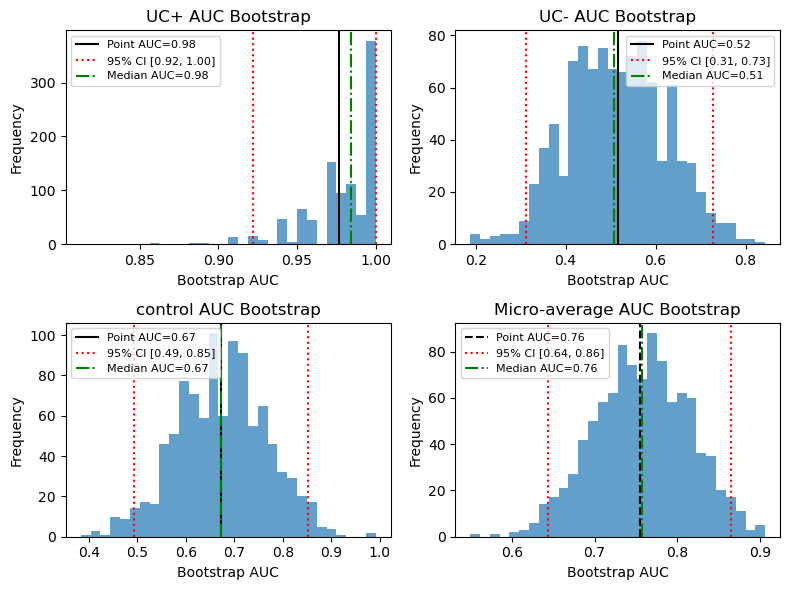

In [66]:
# use the bootrap AUC histgogram function to plot the histograms for each class and the micro average
fig, ax_dict = plt.subplot_mosaic(
    [["A", "B"],  ["C", "D"]], figsize=(8, 6), layout="constrained"
)
plot_auc_bootstrap_histograms(res, ax_dict=ax_dict)
plt.tight_layout()
plt.savefig(figures + 'ibd_auc_bootstrap_histograms.pdf', bbox_inches='tight')
plt.show()

In [67]:
roc_auc_score(y, y_score, average="macro", multi_class="ovr")


np.float64(0.7213541666666666)

In [68]:
roc_auc_score(y, y_score, average="micro", multi_class="ovr")

np.float64(0.7552083333333334)

In [69]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as transforms
import re
from svgpathtools import svg2paths
from svgpath2mpl import parse_path
import matplotlib.path as mpath # Import matplotlib.path
import numpy as np # Import numpy for numerical operations

def extract_color(attr_dict):
    """
    Helper function to find the color of a path.
    SVGs store colors either in a 'fill' attribute or inside a 'style' string.
    """
    # 1. Check direct fill attribute
    if 'fill' in attr_dict and attr_dict['fill'] != 'none':
        return attr_dict['fill']

    # 2. Check inside the style attribute (e.g., style="fill:#FFFFFF;")
    if 'style' in attr_dict:
        match = re.search(r'fill:\s*([^;]+)', attr_dict['style'])
        if match and match.group(1) != 'none':
            return match.group(1)

    # Default to a dark grey if no fill is found (helpful for outlines)
    return "#333333"
"#070505"
def place_svg_on_ax(ax, svg_filepath, x_data_center, y_data_center, desired_width_in_data_units):
    """
    Places an SVG vector graphic on a Matplotlib Axes object, preserving its aspect ratio
    even if the axes' data aspect ratio is not equal.

    Args:
        ax (matplotlib.axes.Axes): The Matplotlib axes to draw on.
        svg_filepath (str): The path to the SVG file.
        x_data_center (float): The x-coordinate (in data units) for the center of the SVG.
        y_data_center (float): The y-coordinate (in data units) for the center of the SVG.
        desired_width_in_data_units (float): The desired width of the SVG in axes' data units.
    """
    paths, attributes = svg2paths(svg_filepath)

    # Calculate overall bounding box to normalize scaling
    min_x, max_x, min_y, max_y = float('inf'), float('-inf'), float('inf'), float('-inf')
    for path in paths:
        if path.bbox() is not None:
            px_min_x, px_max_x, px_min_y, px_max_y = path.bbox()
            min_x = min(min_x, px_min_x)
            max_x = max(max_x, px_max_x)
            min_y = min(min_y, px_min_y)
            max_y = max(max_y, px_max_y)

    svg_width = max_x - min_x
    svg_height = max_y - min_y

    # Calculate the base scale for x, based on desired width in data units
    base_scale_factor = desired_width_in_data_units / svg_width

    # Get the transformation matrix from data coordinates to display coordinates
    trans_data_matrix = ax.transData.get_matrix()

    # Calculate the effective scaling factors for x and y in display coordinates
    # These are the lengths of the unit vectors of the data coordinate system in display space
    scale_x_in_display = np.sqrt(trans_data_matrix[0,0]**2 + trans_data_matrix[1,0]**2)
    scale_y_in_display = np.sqrt(trans_data_matrix[0,1]**2 + trans_data_matrix[1,1]**2)

    # Calculate the compensation factor needed to maintain aspect ratio on screen
    # If scale_y_in_display is greater than scale_x_in_display, it means y-units are stretched,
    # so we need to compress our y-scaling to counteract it.
    # If scale_x_in_display is greater, y-units are compressed, so we need to expand y-scaling.
    compensation_factor = 1.0
    if scale_x_in_display != 0 and scale_y_in_display != 0:
        compensation_factor = scale_x_in_display / scale_y_in_display

    print(f"--- Debugging SVG Placement ---")
    print(f"SVG original size: ({svg_width:.2f}, {svg_height:.2f})")
    print(f"Desired width in data units: {desired_width_in_data_units:.2f}")
    print(f"Base scale factor (X): {base_scale_factor:.4f}")
    print(f"Matplotlib X scale (data to display): {scale_x_in_display:.2f} px/data_unit")
    print(f"Matplotlib Y scale (data to display): {scale_y_in_display:.2f} px/data_unit")
    print(f"Calculated Y-axis compensation factor: {compensation_factor:.4f}")

    # Calculate SVG's center in its own coordinate system
    svg_center_x = min_x + svg_width / 2
    svg_center_y = min_y + svg_height / 2

    # Calculate translation amounts to position the scaled and flipped SVG's center at (x_data_center, y_data_center)
    # Matplotlib's Y-axis is inverted relative to SVG, so adjust for that flip.
    translate_x = x_data_center - (svg_center_x * base_scale_factor)
    translate_y = y_data_center + (svg_center_y * base_scale_factor * compensation_factor) # '+' because Y is flipped

    # Create the combined affine transformation
    # Apply base_scale_factor for X, and base_scale_factor * compensation_factor for Y (with flip)
    mouse_transform = transforms.Affine2D() \
        .scale(base_scale_factor, -base_scale_factor * compensation_factor) \
        .translate(translate_x, translate_y) \
        + ax.transData

    # Loop through every piece of the mouse and add it to the plot
    for path, attr in zip(paths, attributes):
        if 'd' in attr:
            # Parse the SVG path string into an svgpath2mpl Path object
            mpl_path = parse_path(attr['d'])

            # Explicitly create a new Matplotlib Path object from the parsed path's vertices and codes
            matplotlib_path = mpath.Path(mpl_path.vertices, mpl_path.codes)

            color = extract_color(attr)

            patch = patches.PathPatch(
                matplotlib_path, # Use the newly constructed Matplotlib Path
                facecolor=color,
                edgecolor='none',
                transform=mouse_transform,
                clip_on=False
            )
            ax.add_patch(patch)


/var/folders/6w/fbmvs0s92sjf4q_9pttw7kxr0000gp/T/ipykernel_9227/2905702134.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


--- Debugging SVG Placement ---
SVG original size: (117.17, 122.88)
Desired width in data units: 0.20
Base scale factor (X): 0.0017
Matplotlib X scale (data to display): 300.00 px/data_unit
Matplotlib Y scale (data to display): 120.00 px/data_unit
Calculated Y-axis compensation factor: 2.5000


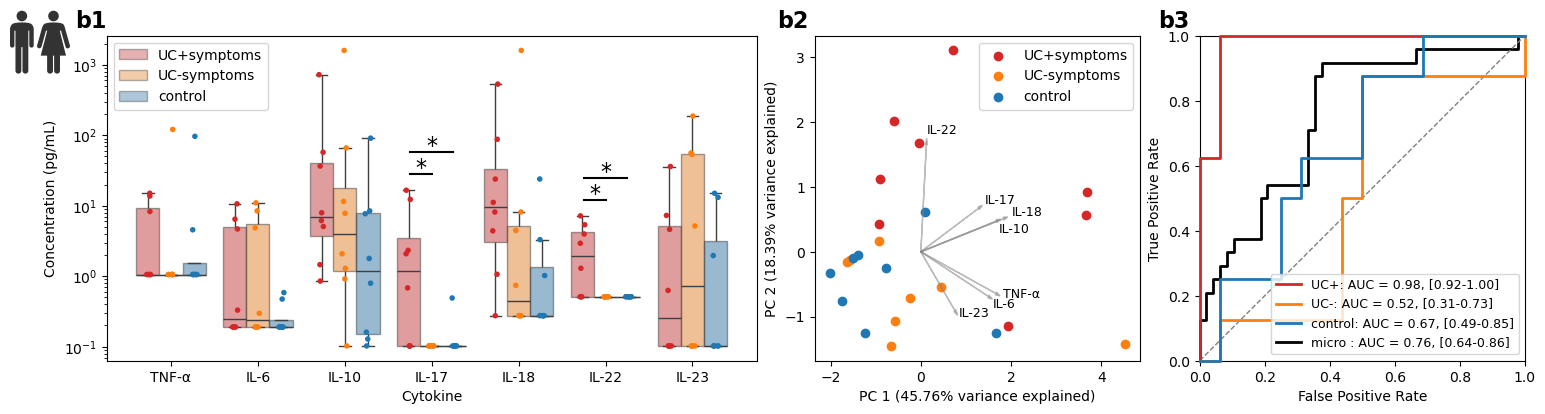

In [70]:
# add credible intervals to the previous roc plot



mosaic = """
AABC
"""
fig, ax_dict = plt.subplot_mosaic(mosaic,figsize=(15, 6), layout='constrained')

ax=ax_dict['A']



sns.boxplot(data=df_plotting_melt, ax=ax, x='protein', y='value', hue='type', 
                 log_scale=10, boxprops={'alpha': 0.5}, showfliers=False, 
                 dodge=True, palette=color_dict)
sns.stripplot(data=df_plotting_melt, x='protein', y='value', hue='type',
              dodge=True, ax=ax, size=4, palette=color_dict)

# Add significance annotations
add_significance_annotations(ax, pairwise_df, df_plotting_melt, fontsize=16)

# Customize plot
ax.set_ylabel('Concentration (pg/mL)')
ax.set_xlabel('Cytokine')

# Rotate x-axis labels for better readability
ax.set_box_aspect(0.5)
# Add legend for significance levels
significance_legend = [
    mpatches.Patch(color='none', label='* p < 0.05'),
    mpatches.Patch(color='none', label='** p < 0.01'), 
    mpatches.Patch(color='none', label='*** p < 0.001'),
    mpatches.Patch(color='none', label='ns = not significant')
]
ax.legend_.remove()
# Get existing legend and add significance legend
#handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[0:3] , labels[0:3], loc='upper left')

current_labels = ax.get_xticklabels()
new_labels = []
for label in current_labels:
    cytokine = label.get_text()
    new_label = display_names.get(cytokine, cytokine)  # Use original if not in dictionary
    new_labels.append(new_label)
ax.set_xticklabels(new_labels)

ax=ax_dict['B']

for target_name in pca_df['Target'].unique():
    subset = pca_df[pca_df['Target'] == target_name]
    ax.scatter(subset['PC1'], subset['PC2'], label=target_name, color=color_dict[target_name])

ax.set_xlabel(f'PC 1 ({explained_variance_pc1:.2f}% variance explained)')
ax.set_ylabel(f'PC 2 ({explained_variance_pc2:.2f}% variance explained)')

ax.legend()
#ax.grid(True)
# for IL10 move the label slightly down to avoid overlap with the other label

for i, cytokine in enumerate(data.columns):
    if cytokine == 'IL10':
        text_y_shift = -0.1
        text_x_shift = -0.05 
    elif cytokine == 'IL6':
        text_y_shift = -0.05
        text_x_shift = -0.025
    else:
        text_x_shift = 0
        text_y_shift = 0  
    ax.arrow(0, 0, 
              loadings.T[0, i]*arrow_scale,  # Scale arrows for visibility
              loadings.T[1, i]*arrow_scale, 
              color='gray', alpha=0.5, head_width=0.05, head_length=0.1, lw=1)
    ax.text((loadings.T[0, i]+text_x_shift)*text_scale, 
             (loadings.T[1, i]+text_y_shift)*text_scale, 
             display_names[cytokine], 
             color='black', 
             fontsize=9)



ax.set_box_aspect(1)
ax=ax_dict['C']




# ax.plot(
#     fpr["macro"],
#     tpr["macro"],
#     label=f"macro : AUC = {roc_auc['macro']:0.2f}, [{res['auc_ci']['macro'][0]:0.2f}-{res['auc_ci']['macro'][1]:0.2f}]",
#     color="black",
#     linestyle=":",
#     linewidth=lw,
# )

colors = cycle(["tab:red", "tab:orange", "tab:blue"])
class_name = ['UC+','UC-','control']
for i, color in zip(range(n_classes), colors):
    ax.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=lw,
        label=class_name[i] + f": AUC = {roc_auc[i]:0.2f}, [{res['auc_ci'][i][0]:0.2f}-{res['auc_ci'][i][1]:0.2f}]",
        #alpha=0.7,
        zorder=3
    )

ax.plot(
    fpr["micro"],
    tpr["micro"],
    label=f"micro : AUC = {roc_auc['micro']:0.2f}, [{res['auc_ci']['micro'][0]:0.2f}-{res['auc_ci']['micro'][1]:0.2f}]",
    color="black",
    linestyle="-",
    linewidth=lw,
)


ax.set_box_aspect(1)
for artist in ax.get_children():
    artist.set_clip_on(False)

ax.plot([0, 1], [0, 1],"--", color='gray', lw=1)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.legend(loc="lower right", fontsize=9)#bbox_to_anchor=(0.5, -0.2), loc='upper center')


#add a,b,c labels to subplots
ax=ax_dict['A']
ax.text(0, 1.08, 'b1', transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='right')
ax=ax_dict['B']
ax.text(-0.02, 1.08, 'b2', transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='right')
ax=ax_dict['C']
ax.text(-0.03, 1.08, 'b3', transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='right')


ax=fig.add_axes([0 ,0.4, 0.2, .2]) # [left, bottom, width, height] in figure coordinates
ax.axis('off')
place_svg_on_ax(ax, human_svg_path, 0.0, 1.8, .2)


plt.savefig(figures + 'ibd_main_figure.pdf', bbox_inches='tight')